In [238]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

#https://arxiv.org/pdf/1609.03499
# • The video continues the implementation of a character-level language model based on a multi-layer perceptron 
# (MLP) architecture.
# • The model predicts the next character based on the previous three characters using one hidden layer with 
# 10 neurons.
# • The goal is to extend the architecture to take more characters as input and deepen the model so information
# is fused progressively rather than all at once.
# • The resulting deeper architecture resembles the WaveNet model (2016), originally designed for audio
# sequences but conceptually similar for language modeling tasks.
# • The WaveNet approach uses a hierarchical, tree-like structure to fuse information from previous
#     characters for prediction.



In [239]:

# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [240]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [241]:

# shuffle up the words
import random
random.seed(42)
random.shuffle(words)

In [29]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [30]:
for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

... --> y
..y --> u
.yu --> h
yuh --> e
uhe --> n
hen --> g
eng --> .
... --> d
..d --> i
.di --> o
dio --> n
ion --> d
ond --> r
ndr --> e
dre --> .
... --> x
..x --> a
.xa --> v
xav --> i
avi --> e


In [31]:
# • The data consists of 182,000 examples where each example is a sequence of three characters predicting the 
# fourth.
# • Layers such as Linear, BatchNorm1D, and Tanh were implemented as modular building blocks, mirroring
# PyTorch’s API style.
# • BatchNorm1D is a complex layer with running means and variances updated outside backpropagation
# using exponential moving averages and behaves differently during training and evaluation modes.
# • The model parameters and optimization steps remain consistent with previous work.
# • The initial validation loss is around 2.10, generating plausible but imperfect name-like samples.


In [43]:
 #Near copy paste of the layers we have developed in Part 3

# -----------------------------------------------------------------------------------------------
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      # if x.ndim == 2:
      #   dim = 0
      # elif x.ndim == 3:
      #   dim = (0,1)
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
# class Embedding:
  
#   def __init__(self, num_embeddings, embedding_dim):
#     self.weight = torch.randn((num_embeddings, embedding_dim))
    
#   def __call__(self, IX):
#     self.out = self.weight[IX]
#     return self.out
  
#   def parameters(self):
#     return [self.weight]

# # -----------------------------------------------------------------------------------------------
# class FlattenConsecutive:
  
#   def __init__(self, n):
#     self.n = n
    
#   def __call__(self, x):
#     B, T, C = x.shape
#     x = x.view(B, T//self.n, C*self.n)
#     if x.shape[1] == 1:
#       x = x.squeeze(1)
#     self.out = x
#     return self.out
  
#   def parameters(self):
#     return []

# -----------------------------------------------------------------------------------------------
# class Sequential:
  
#   def __init__(self, layers):
#     self.layers = layers
  
#   def __call__(self, x):
#     for layer in self.layers:
#       x = layer(x)
#     self.out = x
#     return self.out
  
#   def parameters(self):
#     # get parameters of all layers and stretch them out into one list
#     return [p for layer in self.layers for p in layer.parameters()]

In [44]:
torch.manual_seed(42)

In [45]:

# original network
# n_embd = 10 # the dimensionality of the character embedding vectors
# n_hidden = 300 # the number of neurons in the hidden layer of the MLP
# model = Sequential([
#   Embedding(vocab_size, n_embd),
#   FlattenConsecutive(8), Linear(n_embd * 8, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
#   Linear(n_hidden, vocab_size),
# ])

# n_embd = 24 # the dimensionality of the character embedding vectors
# n_hidden = 128 # the number of neurons in the hidden layer of the MLP

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
C= torch.randn((vocab_size,n_embd))
layers = [
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
]

# parameter init
with torch.no_grad():
  layers[-1].weight *= 0.1 # last layer make less confident

#parameters = model.parameters()
parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


In [46]:
 #same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1)
  for layer in layers:
      x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
          p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  

      0/ 200000: 3.2966
  10000/ 200000: 2.2322
  20000/ 200000: 2.4111
  30000/ 200000: 2.1004
  40000/ 200000: 2.3157
  50000/ 200000: 2.2104
  60000/ 200000: 1.9653
  70000/ 200000: 1.9767
  80000/ 200000: 2.6738
  90000/ 200000: 2.0837
 100000/ 200000: 2.2730
 110000/ 200000: 1.7087
 120000/ 200000: 2.3243
 130000/ 200000: 2.2512
 140000/ 200000: 2.0113
 150000/ 200000: 1.8195
 160000/ 200000: 1.7985
 170000/ 200000: 2.2206
 180000/ 200000: 2.0566
 190000/ 200000: 2.1030


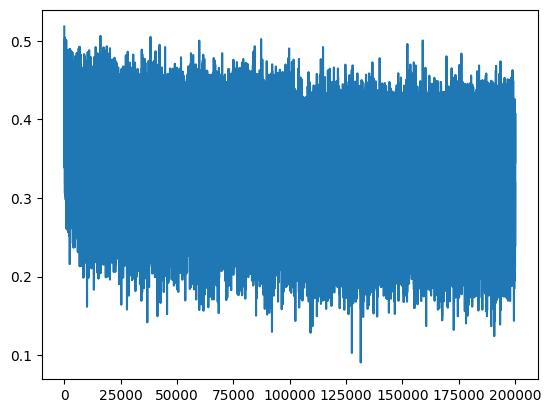

In [47]:
plt.plot(lossi)

In [49]:
# put layers into eval mode (needed for batchnorm especially)
for layer in layers:
  layer.training = False

In [52]:
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x]
  x = emb.view(emb.shape[0],-1)
  for layer in layers:
      x = layer(x)
  #logits = model(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0621414184570312
val 2.109346389770508


In [55]:
# sample from the model
for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      #logits = model(torch.tensor([context]))
      emb = C[torch.tensor([context])]
      x = emb.view(emb.shape[0],-1)   
      for layer in layers:
         x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

ivon.
fanili.
thoommasamiel.
emmadery.
andr.
aleigh.
kelynnie.
jazul.
carleen.
jah.
jorra.
alaya.
shonan.
vishylaharia.
juna.
vio.
orven.
meriell.
laiye.
zefina.


In [57]:
#code refactoring to the above code will start from here 

#Learning rate decay and smoothing of loss curves:
# • Using a tensor view operation to reshape data allows averaging over multiple batches for smoother loss visualization.
# • Learning rate decay removes excess “energy” and helps the optimizer settle in a local minimum, improving training stability.


#  Code Refactoring and PyTorchification
# • The speaker refactors the model to simplify the forward pass by moving special
#operations (embedding lookup and tensor flattening) into dedicated modules.
# • Custom modules for embedding and flattening are implemented, mirroring PyTorch’s nn.
#Embedding and nn.Flatten.
# • A sequential container module is implemented to hold layers and manage forward passes,
#parameters, and simplify the model API, mimicking PyTorch’s nn.Sequential.
# • This refactoring drastically simplifies forward pass code, training, evaluation, and
#sampling calls.
# • A training bug caused by batchnorm being in training mode while evaluating small
#batch sizes is identified and fixed by setting batchnorm to evaluation mode when sampling.


In [58]:
lossi

[0.5180676579475403,
 0.5164594054222107,
 0.507362961769104,
 0.507546603679657,
 0.4992470443248749,
 0.5014019012451172,
 0.5049523115158081,
 0.48866209387779236,
 0.4999050199985504,
 0.4899313449859619,
 0.48290085792541504,
 0.4678862392902374,
 0.47354596853256226,
 0.4671005606651306,
 0.4983521103858948,
 0.488560289144516,
 0.4746759831905365,
 0.4340841472148895,
 0.4748539924621582,
 0.4747598171234131,
 0.47420236468315125,
 0.4413873255252838,
 0.43614792823791504,
 0.47235915064811707,
 0.4477596879005432,
 0.5066854953765869,
 0.45710891485214233,
 0.4839150011539459,
 0.4422481954097748,
 0.43794941902160645,
 0.4660780727863312,
 0.4521620571613312,
 0.4739436209201813,
 0.4503820240497589,
 0.459418386220932,
 0.4598572552204132,
 0.43938320875167847,
 0.4340120553970337,
 0.4651739299297333,
 0.48031508922576904,
 0.4769342243671417,
 0.4656699299812317,
 0.4417915344238281,
 0.4360899031162262,
 0.46380212903022766,
 0.3866958022117615,
 0.4942513406276703,
 0.491

In [59]:
torch.arange(10)

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [60]:
torch.arange(10).view(2,5)

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [61]:
torch.arange(10).view(5,2)

tensor([[0, 1],
        [2, 3],
        [4, 5],
        [6, 7],
        [8, 9]])

In [62]:
torch.arange(10).view(5,-1)

tensor([[0, 1],
        [2, 3],
        [4, 5],
        [6, 7],
        [8, 9]])

In [63]:
torch.tensor(lossi).view(-1,1000).shape

torch.Size([200, 1000])

In [64]:
torch.tensor(lossi).view(-1,1000).mean(1).shape

torch.Size([200])

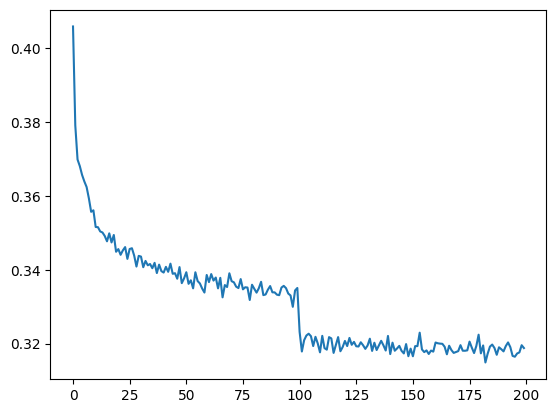

In [66]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [71]:
 #Near copy paste of the layers we have developed in Part 3

# -----------------------------------------------------------------------------------------------
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      # if x.ndim == 2:
      #   dim = 0
      # elif x.ndim == 3:
      #   dim = (0,1)
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Embedding:
  
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))
    
  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out
  
  def parameters(self):
    return [self.weight]

# # -----------------------------------------------------------------------------------------------
class Flatten:
  
  def __call__(self, x):
    self.out = x.view(x.shape[0],-1)
    return self.out
      
#Embedding and flattening operations are converted into modular layers to be 
    #included in the layers list rather than treated as special cases. 
    #https://docs.pytorch.org/docs/stable/generated/torch.nn.Embedding.html
    #https://docs.pytorch.org/docs/stable/generated/torch.nn.Flatten.html
    
  
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
# class Sequential:
  
#   def __init__(self, layers):
#     self.layers = layers
  
#   def __call__(self, x):
#     for layer in self.layers:
#       x = layer(x)
#     self.out = x
#     return self.out
  
#   def parameters(self):
#     # get parameters of all layers and stretch them out into one list
#     return [p for layer in self.layers for p in layer.parameters()]

In [72]:
torch.manual_seed(42)

In [73]:


n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
#C= torch.randn((vocab_size,n_embd))
layers = [
  Embedding(vocab_size, n_embd),
  Flatten(),
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
]

# parameter init
with torch.no_grad():
  layers[-1].weight *= 0.1 # last layer make less confident

#parameters = model.parameters()
parameters = [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


In [76]:
 #same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  x = Xb
  for layer in layers:
      x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
          p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  break

      0/ 200000: 2.0061


In [75]:
#pytorch containers :
#https://docs.pytorch.org/docs/stable/nn.html#containers

In [77]:
 #Near copy paste of the layers we have developed in Part 3

# -----------------------------------------------------------------------------------------------
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      # if x.ndim == 2:
      #   dim = 0
      # elif x.ndim == 3:
      #   dim = (0,1)
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Embedding:
  
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))
    
  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out
  
  def parameters(self):
    return [self.weight]

# # -----------------------------------------------------------------------------------------------
class Flatten:
  
  def __call__(self, x):
    self.out = x.view(x.shape[0],-1)
    return self.out
      
#Embedding and flattening operations are converted into modular layers to be 
    #included in the layers list rather than treated as special cases. 
    #https://docs.pytorch.org/docs/stable/generated/torch.nn.Embedding.html
    #https://docs.pytorch.org/docs/stable/generated/torch.nn.Flatten.html
    
  
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
#https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html
class Sequential:
  
  def __init__(self, layers):
    self.layers = layers
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out
  
  def parameters(self):
    # get parameters of all layers and stretch them out into one list
    return [p for layer in self.layers for p in layer.parameters()]

In [78]:
torch.manual_seed(42)

In [79]:


n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
#C= torch.randn((vocab_size,n_embd))
model = Sequential([
  Embedding(vocab_size, n_embd),
  Flatten(),
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
#parameters = [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12097


In [107]:
 #same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  logits = model(Xb)
  # x = Xb
  # for layer in layers:
  #     x = layer(x)
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
          p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

 # break

      0/ 200000: 3.2832
  10000/ 200000: 2.0641
  20000/ 200000: 1.9702
  30000/ 200000: 1.8742
  40000/ 200000: 2.5191
  50000/ 200000: 2.0647
  60000/ 200000: 1.7851
  70000/ 200000: 2.2023
  80000/ 200000: 2.0790
  90000/ 200000: 2.1911
 100000/ 200000: 1.8534
 110000/ 200000: 1.7812
 120000/ 200000: 1.8502
 130000/ 200000: 1.6836
 140000/ 200000: 2.3008
 150000/ 200000: 2.0084
 160000/ 200000: 2.3449
 170000/ 200000: 2.5355
 180000/ 200000: 1.9810
 190000/ 200000: 2.1493


In [94]:
#plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))
#Increasing Context Length and Naive Scaling
# • The block size (context length) is increased from 3 to 8 characters to provide more 
# context for prediction.
# • The linear layer correspondingly increases in size to handle the larger 
# input dimension (from 3 to 8 characters * embedding size).
# • Naively scaling up the network by increasing input length and layer size improves validation loss from 2.10 to approximately 2.02.
# • Sampled names improve qualitatively, demonstrating that longer context helps, but the model still “crushes” all input characters into a single layer too early.
# • This motivates the need for a hierarchical or progressive fusion architecture resembling WaveNet’s tree-like structure.



In [110]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
  layer.training = False

In [111]:

# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.920366883277893
val 2.0227625370025635


In [102]:
torch.var(torch.tensor([5.0]))

C:\Users\kamba\AppData\Local\Temp\ipykernel_16436\1630907252.py:1: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1839.)
  torch.var(torch.tensor([5.0]))


tensor(nan)

In [112]:
# sample from the model
for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

breely.
bobhaylen.
donnen.
abrie.
demir.
dracest.
tral.
eliyah.
smahir.
brielle.
esteli.
kashad.
serenith.
juselynna.
anadamai.
arylyn.
yara.
kalsey.
antrai.
khalet.


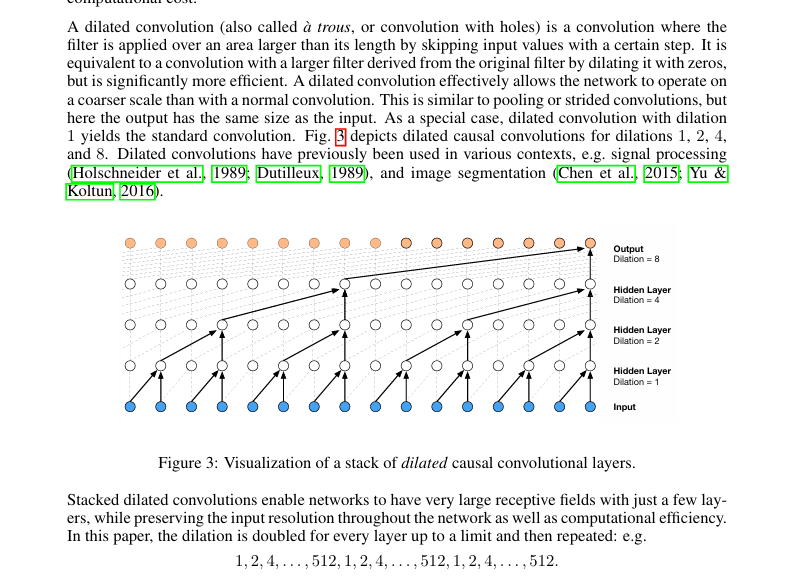

In [103]:
#• The input block size is increased from 3 to 8 characters to provide more context 
#for the prediction.
# • The model’s first linear layer increases in size accordingly, 
#leading to more parameters (about 10,000 more).
# • While the naive approach of flattening all characters into one vector 
#and feeding it to a layer works, it squashes information too quickly.
# • Increasing context length alone reduces validation loss from 2.10 to about
#2.02, and sampling quality improves, showing better name-like outputs.
# • This serves as a baseline before implementing the hierarchical fusion strategy
#inspired by WaveNet.



#in the wavenet case so you see in the wavenet when we are trying to make the
#prediction for the next character in the sequence it is a function of the previous 
#characters that are feeding that feed in but not all of these different characters 
#are not just crushed to a single layer and then you have a sandwich they are crushed
#slowly so in particular we take two characters and we fuse them into sort of like
#a diagram representation and we do that for all these characters consecutively and 
#then we take the bigrams and we fuse



#those into four character level chunks and then we fuse that again and
#so we do that in this like tree-like hierarchical manner so we fuse the 
#information from the previous context slowly into the network as it gets
#deeper and so this is the kind of architecture that we want to implement
#now in the wave Nets case this is a visualization of a stack of dilated 
#causal convolution layers and this makes it sound very scary but actually
#the idea is very simple and the fact that it's a dilated causal convolution layer
from IPython.display import Image, display
display(Image(filename='wavenet.png'))

In [113]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [114]:

for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> y
.......y --> u
......yu --> h
.....yuh --> e
....yuhe --> n
...yuhen --> g
..yuheng --> .
........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .
........ --> x
.......x --> a
......xa --> v
.....xav --> i
....xavi --> e


In [115]:


n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
#C= torch.randn((vocab_size,n_embd))
model = Sequential([
  Embedding(vocab_size, n_embd),
  Flatten(),
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
#parameters = [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

22097


In [117]:
 #same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  logits = model(Xb)
  # x = Xb
  # for layer in layers:
  #     x = layer(x)
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
          p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  

      0/ 200000: 3.3241
  10000/ 200000: 2.0789
  20000/ 200000: 2.4472
  30000/ 200000: 2.2208
  40000/ 200000: 1.6707
  50000/ 200000: 1.8902
  60000/ 200000: 2.1537
  70000/ 200000: 2.0494
  80000/ 200000: 1.8514
  90000/ 200000: 2.3723
 100000/ 200000: 2.4558
 110000/ 200000: 2.3359
 120000/ 200000: 2.2620
 130000/ 200000: 2.1762
 140000/ 200000: 1.8416
 150000/ 200000: 1.9507
 160000/ 200000: 2.2499
 170000/ 200000: 1.7030
 180000/ 200000: 1.8987
 190000/ 200000: 2.0869


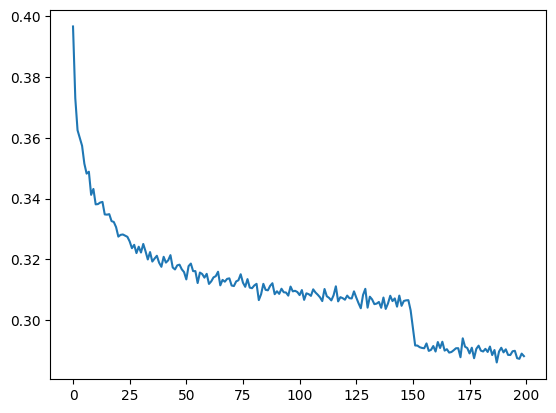

In [118]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [119]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
  layer.training = False

In [120]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.9194120168685913
val 2.032562494277954


In [121]:
# sample from the model
for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

kennona.
dawtap.
aimia.
ashtin.
zalen.
grechyn.
annin.
winsley.
janiel.
sayvie.
jesso.
manaya.
daylan.
reidiana.
beramill.
agary.
deannone.
kulo.
laeren.
dairen.


In [ ]:
# Implementing Hierarchical Progressive Fusion
# • The hierarchical approach progressively merges pairs of characters:
# first pairs of characters, then pairs of bigrams, then pairs of four-grams, etc.,
# forming a tree-like fusion of information.
# • This is implemented by modifying the flattening layer to group consecutive 
# embeddings into chunks of size n (e.g., groups of 2).
# • The linear layers then process these grouped chunks in parallel, exploiting 
# PyTorch’s ability to perform batch matrix multiplication on tensors with 
# multiple batch dimensions.
# • The flattening layer is extended to flatten consecutive elements into a new 
# dimension rather than collapsing all dimensions into one, enabling hierarchical processing.
# • The speaker shows how to implement this flattening efficiently using PyTorch’s 
# view operation, avoiding explicit concatenation.
# • The network now consists of multiple linear-BatchNorm-Tanh blocks that process
# progressively smaller sequences with larger embedding sizes, resembling a hierarchical model.
# • Model parameters are controlled to keep total parameter count similar to the baseline
#     for fair comparison (~22,000 parameters).
# • Initial results show roughly the same validation loss (~2.03) as the naive scaling
# baseline, indicating no immediate performance gain from the hierarchical approach with
# the initial hyperparameters.


In [126]:
ix = torch.randint(0,Xtr.shape[0], (4,))
Xb,Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  0,  0,  0, 11],
        [ 0,  0,  0,  0,  0,  1, 12,  1],
        [ 0,  0,  0,  0,  0,  0,  0, 10],
        [ 0,  0,  0,  0,  0,  0, 12,  1]])

In [127]:
model.layers[0].out.shape # output of embedding layer

torch.Size([4, 8, 10])

In [128]:
model.layers[1].out.shape # output of Flatten layer

torch.Size([4, 80])

In [130]:
model.layers[2].out.shape # output of Linear layer

torch.Size([4, 200])

In [135]:
(torch.randn(4,80) @ torch.randn(80,200) + torch.randn(200)).shape
#et's look at the insides of the linear layer and remind ourselves how it works 
#the linear layer here in the forward pass takes the input X multiplies it with 
#a weight and then optionally adds bias and the weight here is two-dimensional as 
#defined here and the bias is one dimensional here so effectively in terms of the shapes 
#involved what's happening inside this linear layer looks like this right now and I'm 
#using random numbers here but I'm just illustrating the shapes and what happens

#basically a 4 by 80 input comes into the linear layer that's multiplied by this 80 by 
#200 weight Matrix inside and there's a plus 200 bias and the shape of the whole thing 
#that comes out of the linear layer is four by two hundred as we see here now notice here
#by the way that this here will create a 4x200 tensor and then plus 200 there's
#a broadcasting happening here about 4 by 200 broadcasts with 200 uh so everything works 
#here so now the surprising thing that I'd like to show you that you may not expect

#is that this input here that is being multiplied uh doesn't actually have to be 
#two-dimensional this Matrix multiply operator in pytorch is quite powerful and in
#fact you can actually pass in higher dimensional arrays or tensors and everything 
#works fine so for example this could be four by five by eighty and the result in
#that case will become four by five by two hundred you can add as many dimensions
#as you like on the left here and so effectively what's happening is that the matrix
#multiplication only
 #works on the last Dimension and the dimensions before it in the input 
#tensor are left unchanged so that is basically these um these dimensions
#on the left are all treated as just a batch Dimension so we can have multiple
#batch dimensions and then in parallel over all those Dimensions we are doing 
#the matrix multiplication on the last dimension so this is quite convenient
#because we can use that in our Network now because remember that we have these
#eight characters coming in and we don't want to now uh flatten all


torch.Size([4, 200])

In [132]:
(torch.randn(4,5,80) @ torch.randn(80,200) + torch.randn(200)).shape

torch.Size([4, 5, 200])

In [133]:
(torch.randn(4,5,2,80) @ torch.randn(80,200) + torch.randn(200)).shape

torch.Size([4, 5, 2, 200])

In [137]:
(torch.randn(4,4,20) @ torch.randn(20,200) + torch.randn(200)).shape


torch.Size([4, 4, 200])

In [139]:
list(range(10))[1::2]

[1, 3, 5, 7, 9]

In [142]:
list(range(10))[::2]

[0, 2, 4, 6, 8]

In [141]:
e = torch.randn(4,8,10) # want this to be 4,4,20 where 10-d vector get concatenated
e.view(4,-1).shape

torch.Size([4, 80])

In [153]:
e = torch.randn(4,8,10) # want this to be 4,4,20 where 10-d vector get concatenated
#e.view(4,-1).shape
torch.cat([e[:, ::2,:],e[:, 1::2, :]],dim=2).shape
explicit = torch.cat([e[:, ::2,:],e[:, 1::2, :]],dim=2)
explicit.shape

torch.Size([4, 4, 20])

In [156]:
(e.view(4,4,20) == explicit).all()

tensor(True)

In [157]:
 #Near copy paste of the layers we have developed in Part 3

# -----------------------------------------------------------------------------------------------
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      # if x.ndim == 2:
      #   dim = 0
      # elif x.ndim == 3:
      #   dim = (0,1)
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Embedding:
  
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))
    
  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out
  
  def parameters(self):
    return [self.weight]

# # -----------------------------------------------------------------------------------------------
class FlattenConsecutive:

  def __init__(self, n):
    self.n = n
      
  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1) #https://docs.pytorch.org/docs/stable/generated/torch.squeeze.html
    self.out = x
    return self.out
      
#Embedding and flattening operations are converted into modular layers to be 
    #included in the layers list rather than treated as special cases. 
    #https://docs.pytorch.org/docs/stable/generated/torch.nn.Embedding.html
    #https://docs.pytorch.org/docs/stable/generated/torch.nn.Flatten.html
    
  
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
#https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html
class Sequential:
  
  def __init__(self, layers):
    self.layers = layers
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out
  
  def parameters(self):
    # get parameters of all layers and stretch them out into one list
    return [p for layer in self.layers for p in layer.parameters()]

In [164]:


n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
#C= torch.randn((vocab_size,n_embd))
model = Sequential([
  Embedding(vocab_size, n_embd),
#  FlattenConsecutive(8),
  FlattenConsecutive(block_size),
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
#parameters = [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

22097


170897


In [159]:
ix = torch.randint(0,Xtr.shape[0], (4,))
Xb,Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  1,  1, 18,  1, 22],
        [ 0,  0,  0,  0,  0, 11,  1, 12]])

In [163]:
#blocksize =8 
for layer in model.layers:
  print(layer.__class__.__name__,':',tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 80)
Linear : (4, 200)
BatchNorm1d : (4, 200)
Tanh : (4, 200)
Linear : (4, 27)


In [166]:


n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
#C= torch.randn((vocab_size,n_embd))
model = Sequential([
  Embedding(vocab_size, n_embd),
#  FlattenConsecutive(8),
  FlattenConsecutive(2),Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  #Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2),Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2),Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
#parameters = [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

170897


In [167]:
ix = torch.randint(0,Xtr.shape[0], (4,))
Xb,Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0, 14,  1, 25,  5, 12],
        [ 0,  0,  0,  0,  0,  0,  0, 13],
        [ 0,  0,  0,  0,  0,  0, 26,  1],
        [ 0,  0,  0,  1,  2,  9,  7,  1]])

In [168]:
#blocksize =8 
for layer in model.layers:
  print(layer.__class__.__name__,':',tuple(layer.out.shape))

Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 200)
BatchNorm1d : (4, 4, 200)
Tanh : (4, 4, 200)
FlattenConsecutive : (4, 2, 400)
Linear : (4, 2, 200)
BatchNorm1d : (4, 2, 200)
Tanh : (4, 2, 200)
FlattenConsecutive : (4, 400)
Linear : (4, 200)
BatchNorm1d : (4, 200)
Tanh : (4, 200)
Linear : (4, 27)


In [169]:
logits.shape

torch.Size([4, 27])

In [170]:
 #same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  logits = model(Xb)
  # x = Xb
  # for layer in layers:
  #     x = layer(x)
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
          p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  

      0/ 200000: 3.3207
  10000/ 200000: 2.2232
  20000/ 200000: 1.9338
  30000/ 200000: 2.0546
  40000/ 200000: 2.1725
  50000/ 200000: 2.3407
  60000/ 200000: 1.8297
  70000/ 200000: 2.1229
  80000/ 200000: 2.3071
  90000/ 200000: 2.2034
 100000/ 200000: 2.0850
 110000/ 200000: 1.7140
 120000/ 200000: 1.9407
 130000/ 200000: 2.0472
 140000/ 200000: 1.8735
 150000/ 200000: 1.9582
 160000/ 200000: 1.8722
 170000/ 200000: 1.8014
 180000/ 200000: 2.0243
 190000/ 200000: 1.7723


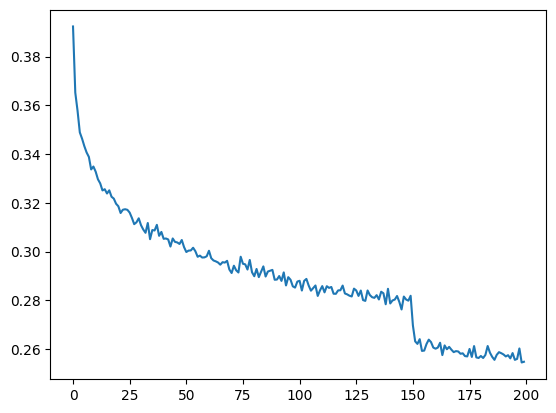

In [171]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [172]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
  layer.training = False

In [173]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.7758597135543823
val 1.9823052883148193


In [177]:


n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 68 # the number of neurons in the hidden layer of the MLP
#C= torch.randn((vocab_size,n_embd))
model = Sequential([
  Embedding(vocab_size, n_embd),
#  FlattenConsecutive(8),
  FlattenConsecutive(2),Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  #Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2),Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2),Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
#parameters = [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

22397


In [ ]:
#Initial results show roughly the same validation loss (~2.03) as the
#naive scaling baseline, indicating no immediate performance gain from
#the hierarchical approach with the initial hyperparameters.

In [185]:
ix = torch.randint(0,Xtr.shape[0], (32,))
Xb,Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([32, 8])


tensor([[ 0,  0,  0,  0,  0,  0, 18,  5],
        [ 0,  0,  2, 18,  9, 20, 20,  9],
        [ 3,  8, 18,  9, 19, 20,  9,  5],
        [ 0,  0,  0,  0, 16,  5, 14,  5],
        [ 0,  0,  0,  0,  0, 10, 15, 19],
        [ 0, 19,  5, 22,  5, 18, 21, 19],
        [15,  6,  9,  1, 18, 15, 19,  5],
        [ 0, 11,  1, 25,  2, 18,  5,  5],
        [ 0,  0,  0,  0,  0,  5, 19, 20],
        [ 0,  0,  0,  0,  0,  0,  0,  1],
        [ 0,  0,  0, 19,  8, 25,  1, 14],
        [ 0,  0,  0,  0,  0,  1,  2,  8],
        [ 0,  0,  0,  0,  0, 11, 25, 14],
        [ 0,  0,  0,  0, 13,  1, 12,  1],
        [ 0, 19, 25, 14,  3,  5, 18,  5],
        [ 0,  0,  0,  0,  0,  0,  0,  2],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  1],
        [ 0,  0,  0,  0,  0,  0,  0, 11],
        [ 0,  0,  0,  0,  0,  0, 11,  1],
        [ 0,  0,  0,  0,  0,  0,  0, 10],
        [ 0,  0,  0,  0,  0, 10, 21,  2],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0, 13, 2

In [186]:
#n_hidden=68
for layer in model.layers:
  print(layer.__class__.__name__,':',tuple(layer.out.shape))

Embedding : (32, 8, 10)
FlattenConsecutive : (32, 4, 20)
Linear : (32, 4, 68)
BatchNorm1d : (32, 4, 68)
Tanh : (32, 4, 68)
FlattenConsecutive : (32, 2, 136)
Linear : (32, 2, 68)
BatchNorm1d : (32, 2, 68)
Tanh : (32, 2, 68)
FlattenConsecutive : (32, 136)
Linear : (32, 68)
BatchNorm1d : (32, 68)
Tanh : (32, 68)
Linear : (32, 27)


In [ ]:
#BatchNorm1D Layer Bug and Fix
# • BatchNorm1D was originally designed to work with 2D tensors (batch x features),
# but the new hierarchical model produces 3D tensors (batch x groups x features).
# • The implemented BatchNorm1D incorrectly computes mean and variance only over the
# batch dimension (dim=0), thus maintaining separate statistics for each group within
#     the batch dimension.
# • The fix involves computing mean and variance over both batch and group dimensions
# (dim=(0,1)) to aggregate statistics properly for each feature channel.
# • This aligns better with PyTorch’s BatchNorm1D expectations and yields more
#     stable running statistics and better model behavior.
# • After fixing BatchNorm, validation loss improves slightly from 2.029 to 2.022, 
#     showing measurable benefit from proper normalization.


In [187]:
e = torch.randn(32,4,68) 
# torch.cat([e[:, ::2,:],e[:, 1::2, :]],dim=2).shape
# explicit = torch.cat([e[:, ::2,:],e[:, 1::2, :]],dim=2)
# explicit.shape
#https://docs.pytorch.org/docs/stable/generated/torch.mean.html
emean = e.mean(0,keepdim=True)# 1,4 68
evar = e.var(0,keepdim=True)#1,4,68
ehat = (e - emean)/torch.sqrt(evar + 1e-5)
ehat.shape

torch.Size([32, 4, 68])

In [189]:
model.layers[3].running_mean.shape

torch.Size([1, 4, 68])

In [190]:
e = torch.randn(32,4,68) 
# torch.cat([e[:, ::2,:],e[:, 1::2, :]],dim=2).shape
# explicit = torch.cat([e[:, ::2,:],e[:, 1::2, :]],dim=2)
# explicit.shape
#https://docs.pytorch.org/docs/stable/generated/torch.mean.html
emean = e.mean((0,1),keepdim=True)# 1,1 68
evar = e.var((0,1),keepdim=True)#1,1,68
ehat = (e - emean)/torch.sqrt(evar + 1e-5)
ehat.shape

torch.Size([32, 4, 68])

In [191]:
emean.shape

torch.Size([1, 1, 68])

In [192]:
 #Near copy paste of the layers we have developed in Part 3

# -----------------------------------------------------------------------------------------------
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Embedding:
  
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))
    
  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out
  
  def parameters(self):
    return [self.weight]

# # -----------------------------------------------------------------------------------------------
class FlattenConsecutive:

  def __init__(self, n):
    self.n = n
      
  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1) #https://docs.pytorch.org/docs/stable/generated/torch.squeeze.html
    self.out = x
    return self.out
      
#Embedding and flattening operations are converted into modular layers to be 
    #included in the layers list rather than treated as special cases. 
    #https://docs.pytorch.org/docs/stable/generated/torch.nn.Embedding.html
    #https://docs.pytorch.org/docs/stable/generated/torch.nn.Flatten.html
    
  
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
#https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html
class Sequential:
  
  def __init__(self, layers):
    self.layers = layers
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out
  
  def parameters(self):
    # get parameters of all layers and stretch them out into one list
    return [p for layer in self.layers for p in layer.parameters()]

In [259]:


n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 68 # the number of neurons in the hidden layer of the MLP
#C= torch.randn((vocab_size,n_embd))
model = Sequential([
  Embedding(vocab_size, n_embd),
#  FlattenConsecutive(8),
  FlattenConsecutive(2),Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  #Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2),Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2),Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
#parameters = [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

22397


In [260]:
ix = torch.randint(0,Xtr.shape[0], (32,))
Xb,Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
#Xb

torch.Size([32, 8])


In [261]:
#n_hidden=68
for layer in model.layers:
  print(layer.__class__.__name__,':',tuple(layer.out.shape))

Embedding : (32, 8, 10)
FlattenConsecutive : (32, 4, 20)
Linear : (32, 4, 68)
BatchNorm1d : (32, 4, 68)
Tanh : (32, 4, 68)
FlattenConsecutive : (32, 2, 136)
Linear : (32, 2, 68)
BatchNorm1d : (32, 2, 68)
Tanh : (32, 2, 68)
FlattenConsecutive : (32, 136)
Linear : (32, 68)
BatchNorm1d : (32, 68)
Tanh : (32, 68)
Linear : (32, 27)


In [206]:
 #same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  logits = model(Xb)
  # x = Xb
  # for layer in layers:
  #     x = layer(x)
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
          p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  
  

      0/ 200000: 3.5499
  10000/ 200000: 2.3587
  20000/ 200000: 2.1057
  30000/ 200000: 2.1501
  40000/ 200000: 1.9711
  50000/ 200000: 2.1034
  60000/ 200000: 1.9106
  70000/ 200000: 1.9792
  80000/ 200000: 2.5507
  90000/ 200000: 1.8233
 100000/ 200000: 2.3839
 110000/ 200000: 1.8934
 120000/ 200000: 2.3933
 130000/ 200000: 2.4562
 140000/ 200000: 2.1738
 150000/ 200000: 2.0194
 160000/ 200000: 2.1124
 170000/ 200000: 2.1948
 180000/ 200000: 1.4401
 190000/ 200000: 2.6924


In [291]:
model.layers[3].running_mean.shape # should be [1,1,68]


torch.Size([1, 4, 128])

In [292]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train nan
val nan


In [212]:
# original
# train 2.0621414184570312
# val 2.109346389770508

# context
# train 1.920366883277893
# val 2.0227625370025635


# train 1.9194120168685913
# val 2.032562494277954

# flat
# train 1.7758597135543823
# val 1.9823052883148193

# fix bug batchnorm 
# train 1.9357736110687256
# val 2.020726203918457


In [351]:
 #Near copy paste of the layers we have developed in Part 3

# -----------------------------------------------------------------------------------------------
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Embedding:
  
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))
    
  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out
  
  def parameters(self):
    return [self.weight]

# # -----------------------------------------------------------------------------------------------
class FlattenConsecutive:

  def __init__(self, n):
    self.n = n
      
  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1) #https://docs.pytorch.org/docs/stable/generated/torch.squeeze.html
    self.out = x
    return self.out
      
#Embedding and flattening operations are converted into modular layers to be 
    #included in the layers list rather than treated as special cases. 
    #https://docs.pytorch.org/docs/stable/generated/torch.nn.Embedding.html
    #https://docs.pytorch.org/docs/stable/generated/torch.nn.Flatten.html
    
  
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
#https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html
class Sequential:
  
  def __init__(self, layers):
    self.layers = layers
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out
  
  def parameters(self):
    # get parameters of all layers and stretch them out into one list
    return [p for layer in self.layers for p in layer.parameters()]

In [352]:
torch.manual_seed(42);

In [353]:
#Scaling Up Model Capacity and Performance Gains
# • The embedding dimension and hidden units are increased 
# (e.g., embedding dimension from 10 to 24), resulting in ~76,000 parameters.
# • The larger model takes longer to train but achieves validation loss under 
# 2.0 (around 1.993).
# • Despite improvements, training becomes slower and hyperparameter tuning more
# challenging, highlighting the need for better experimental infrastructure.
# • The hierarchical model implementation remains a work in progress without
# incorporating advanced WaveNet features like gated linear units, residual connections,
# or skip connections.


n_embd = 24 # the dimensionality of the character embedding vectors
n_hidden = 128 # the number of neurons in the hidden layer of the MLP
#C= torch.randn((vocab_size,n_embd))
model = Sequential([
  Embedding(vocab_size, n_embd),
#  FlattenConsecutive(8),
  FlattenConsecutive(2),Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  #Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2),Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2),Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
#parameters = [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

76579


In [354]:
ix = torch.randint(0,Xtr.shape[0], (32,))
Xb,Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([32, 8])


tensor([[ 0,  0,  0,  0,  0,  0, 12, 15],
        [ 0,  0,  0,  0, 16, 15, 18, 20],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0, 12,  1, 25,  1, 14, 14],
        [ 0,  0,  0,  1, 12, 20,  1,  9],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  4,  5, 19, 20,  5, 14],
        [ 0,  0,  0,  0,  0,  0,  0, 12],
        [ 0,  0,  0,  0,  0,  0, 23,  1],
        [ 0,  0,  0,  0,  0,  0,  0, 16],
        [ 0,  0,  0,  0,  0,  0,  0, 11],
        [ 0,  0,  0,  0,  0,  0,  0, 21],
        [ 0,  0, 16,  5, 14,  5, 12, 15],
        [ 0,  0,  0,  0,  0, 13, 15, 18],
        [ 0,  0, 13,  1, 12, 15, 14,  5],
        [ 0,  0,  0,  0,  0,  0, 18, 15],
        [ 0,  0, 11, 25, 14,  4,  5, 12],
        [ 0,  0,  0,  0, 11, 25, 12, 25],
        [ 0,  0,  0,  0,  0, 10,  1, 14],
        [ 0,  0,  0,  0,  0,  0, 12, 21],
        [ 0,  0,  0,  0, 15, 12, 21, 23],
        [ 0,  0,  0,  0,  0,  0, 13,  5],
        [ 0,  0,  0,  0, 11, 15,  2,  5],
        [ 8,  1, 13, 13,  1,  4, 1

In [355]:
 #same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  logits = model(Xb)
  # x = Xb
  # for layer in layers:
  #     x = layer(x)
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
          p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

  
  

      0/ 200000: 3.5444
  10000/ 200000: 1.8500
  20000/ 200000: 1.7174
  30000/ 200000: 2.1034
  40000/ 200000: 2.2455
  50000/ 200000: 1.8143
  60000/ 200000: 2.2730
  70000/ 200000: 1.8472
  80000/ 200000: 1.8476
  90000/ 200000: 1.8775
 100000/ 200000: 2.1959
 110000/ 200000: 2.1145
 120000/ 200000: 1.6770
 130000/ 200000: 1.9263
 140000/ 200000: 2.0423
 150000/ 200000: 1.9705
 160000/ 200000: 2.1455
 170000/ 200000: 1.8711
 180000/ 200000: 1.8144
 190000/ 200000: 1.8978


In [356]:

for layer in model.layers:
  print(layer.__class__.__name__,':',tuple(layer.out.shape))

Embedding : (32, 8, 24)
FlattenConsecutive : (32, 4, 48)
Linear : (32, 4, 128)
BatchNorm1d : (32, 4, 128)
Tanh : (32, 4, 128)
FlattenConsecutive : (32, 2, 256)
Linear : (32, 2, 128)
BatchNorm1d : (32, 2, 128)
Tanh : (32, 2, 128)
FlattenConsecutive : (32, 256)
Linear : (32, 128)
BatchNorm1d : (32, 128)
Tanh : (32, 128)
Linear : (32, 27)


In [357]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.8024556636810303
val 1.9847806692123413


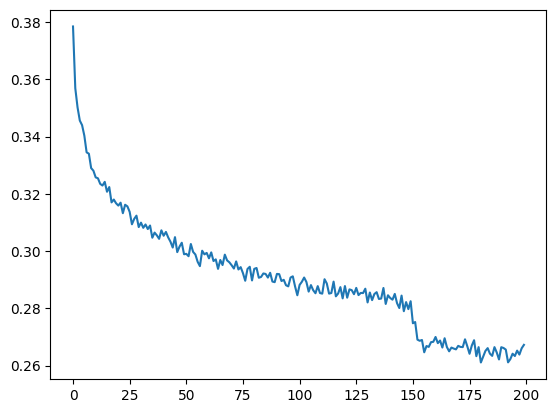

In [358]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [218]:
# original
# train 2.0621414184570312
# val 2.109346389770508

# context
# train 1.920366883277893
# val 2.0227625370025635


# train 1.9194120168685913
# val 2.032562494277954

# flat
# train 1.7758597135543823
# val 1.9823052883148193

# fix bug batchnorm 
# train 1.9357736110687256
# val 2.020726203918457

#scale up the network 
# train 1.8030235767364502
# val 1.9767906665802002

In [ ]:
# Relationship to Convolutional Neural Networks and Efficiency
# • The current MLP-style model processes each output position independently, 
# requiring multiple forward passes to get outputs for all positions in a sequence.
# • Convolutional neural networks (CNNs), like WaveNet, slide filters over sequences,
# computing all outputs simultaneously and efficiently, hiding loops inside optimized CUDA kernels.
# • CNNs also enable reuse of intermediate computations, which are redundantly 
# recalculated in naive MLP implementations.
# • The video’s current implementation corresponds to a single “tree” of calculations
# for one output, whereas CNNs compute the entire sequence in one forward pass.
# • Future lectures will cover dilated causal convolutions, residual connections,
# and skip connections to improve efficiency and expressivity.


In [235]:
# #Scaling Up Model Capacity and Performance Gains
# # • The embedding dimension and hidden units are increased 
# # (e.g., embedding dimension from 10 to 24), resulting in ~76,000 parameters.
# # • The larger model takes longer to train but achieves validation loss under 
# # 2.0 (around 1.993).
# # • Despite improvements, training becomes slower and hyperparameter tuning more
# # challenging, highlighting the need for better experimental infrastructure.
# # • The hierarchical model implementation remains a work in progress without
# # incorporating advanced WaveNet features like gated linear units, residual connections,
# # or skip connections.


# n_embd = 24 # the dimensionality of the character embedding vectors
# n_hidden = 128 # the number of neurons in the hidden layer of the MLP
# #C= torch.randn((vocab_size,n_embd))
# model = Sequential([
#   Embedding(vocab_size, n_embd),
# #  FlattenConsecutive(8),
#   FlattenConsecutive(2),Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
#   #Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
#   FlattenConsecutive(2),Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
#   FlattenConsecutive(2),Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
#   Linear(n_hidden, vocab_size),
# ])

# # parameter init
# with torch.no_grad():
#   layers[-1].weight *= 0.1 # last layer make less confident

# parameters = model.parameters()
# #parameters = [p for layer in layers for p in layer.parameters()]
# print(sum(p.nelement() for p in parameters)) # number of parameters in total
# for p in parameters:
#   p.requires_grad = True

76579


In [331]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [367]:

# sample from the model
for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

C:\Users\kamba\AppData\Local\Temp\ipykernel_16436\2538347266.py:41: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1839.)
  xvar = x.var(0, keepdim=True) # batch variance


RuntimeError: probability tensor contains either `inf`, `nan` or element < 0

In [ ]:
# Relationship to Convolutional Neural Networks and Efficiency
# # • The current MLP-style model processes each output position independently, 
# requiring multiple forward passes to get outputs for all positions in a sequence.
# # • Convolutional neural networks (CNNs), like WaveNet, slide filters over sequences,
# computing all outputs simultaneously and efficiently, hiding loops inside optimized CUDA kernels.
# # • CNNs also enable reuse of intermediate computations, which are redundantly 
# recalculated in naive MLP implementations.
# # • The video’s current implementation corresponds to a single “tree” of calculations 
# for one output, whereas CNNs compute the entire sequence in one forward pass.
# # • Future lectures will cover dilated causal convolutions, residual connections, 
#     and skip connections to improve efficiency and expressivity.

In [368]:
for x,y in zip(Xtr[7:15], Ytr[7:15]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .


In [369]:
# forward a single example:
logits = model(Xtr[[7]])
logits.shape

C:\Users\kamba\AppData\Local\Temp\ipykernel_16436\2538347266.py:41: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1839.)
  xvar = x.var(0, keepdim=True) # batch variance


torch.Size([1, 27])

In [370]:
# forward all of them
logits = torch.zeros(8, 27)
for i in range(8):
  logits[i] = model(Xtr[[7+i]])
logits.shape

C:\Users\kamba\AppData\Local\Temp\ipykernel_16436\2538347266.py:41: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1839.)
  xvar = x.var(0, keepdim=True) # batch variance


torch.Size([8, 27])

In [ ]:
# # Reflections on Development Process and Next Steps
# • The video demonstrates implementing foundational layers and containers similar to
# PyTorch’s torch.nn from scratch, deepening understanding of neural network internals.
# • Challenges include dealing with multi-dimensional tensor shapes, managing batchnorm 
# state, and debugging shape mismatches.
# • The development workflow involves prototyping in Jupyter notebooks and then porting
# code to production repositories for training.
# • The speaker notes the poor quality of PyTorch documentation, emphasizing the need to
# frequently experiment and read source code to understand behavior.
# • Future directions include implementing dilated causal convolutions (WaveNet), 
# recurrent networks (RNNs, LSTMs, GRUs), Transformers, and building better experimental
# harnesses for hyperparameter tuning.
# • The speaker encourages viewers to experiment with the current model and try to beat
# the achieved validation loss with different architectures or hyperparameters.

